# Boarding School Influenza 1978 — Epidemic Prediction

**Dataset:** 14 daily observations from a British boarding school (January–February 1978).

| Variable | Value |
|---|---|
| Population N | 763 boys |
| Total infected | 512 |
| True ρ_final | 512 / 763 ≈ **0.671** |
| `in_bed(t)` | boys currently sick = I(t) (prevalence, not cumulative) |
| I(t)/N | `in_bed(t) / 763` |

For each observation window **k** (first k days visible), the pipeline predicts:
- **ρ_final** — total fraction of population eventually infected
- **model class** — which mechanistic spreading model best fits the dynamics

Both the **DL pipeline** (CNN backbone, two-stage specialist) and the **classical ML baseline** (HGB on hand-crafted features) are evaluated. Graph-structural features (not available for real data) are set to zero.

## 1. Imports & setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Make src/ importable regardless of where the kernel is launched from
SRC_DIR = Path("__file__").resolve().parent.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Pickle compatibility: the .pkl models were saved when the package lived at `dl/`
# (before it was reorganised to `ml/dl/`). Register aliases so joblib can unpickle them.
import ml.dl, ml.dl.wrappers, ml.dl.features, ml.dl.models, ml.dl.mixture_of_experts
for _old, _new in [
    ("dl",                    "ml.dl"),
    ("dl.wrappers",           "ml.dl.wrappers"),
    ("dl.features",           "ml.dl.features"),
    ("dl.models",             "ml.dl.models"),
    ("dl.mixture_of_experts", "ml.dl.mixture_of_experts"),
]:
    sys.modules.setdefault(_old, sys.modules[_new])

from ml.dl.features import extract_features as _dl_extract, FEATURE_NAMES as _TS_FEAT_NAMES

print(f"SRC_DIR: {SRC_DIR}")

SRC_DIR: /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src


## 2. Constants

In [2]:
N_POPULATION   = 763
TOTAL_INFECTED = 512
RHO_FINAL_TRUE = TOTAL_INFECTED / N_POPULATION   # ≈ 0.6711

DATA_PATH   = SRC_DIR / "data" / "influenza_england_1978_school.csv"
ML_DATA_DIR = SRC_DIR / "ml" / "ml_data"
RESULTS_DIR = SRC_DIR / "results" / "boarding_school"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Days of early observation to evaluate
OBS_WINDOWS = [1, 2, 3, 4, 5, 7]

MODEL_NAMES = ["SIR", "SIS", "BP", "WTM", "H1", "H2", "H3", "H4", "H5", "H6"]

print(f"True rho_final = {TOTAL_INFECTED}/{N_POPULATION} = {RHO_FINAL_TRUE:.4f}")

True rho_final = 512/763 = 0.6710


## 3. Load and inspect the data

In [3]:
df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
display(df_raw)

# Convert in_bed → I(t)/N
I_norm = (df_raw["in_bed"].values / N_POPULATION).astype(np.float32)
T      = len(I_norm)
days   = np.arange(1, T + 1)

peak_day = int(I_norm.argmax()) + 1
print(f"\nSeries length : {T} days")
print(f"Peak prevalence: day {peak_day}  →  {int(I_norm.max()*N_POPULATION)} boys in bed  (I/N = {I_norm.max():.4f})")

,date,in_bed,convalescent
0,1978-01-22,3,0
1,1978-01-23,8,0
2,1978-01-24,26,0
3,1978-01-25,76,0
4,1978-01-26,225,9
5,1978-01-27,298,17
6,1978-01-28,258,105
7,1978-01-29,233,162
8,1978-01-30,189,176
9,1978-01-31,128,166



Series length : 14 days
Peak prevalence: day 6  →  298 boys in bed  (I/N = 0.3906)


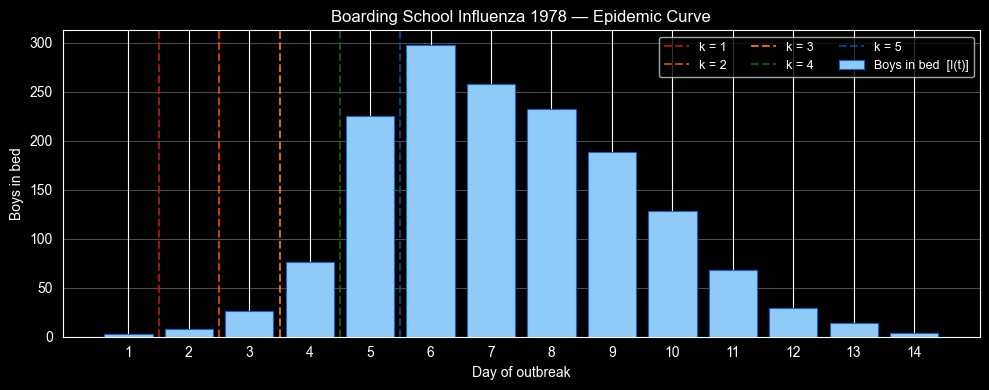

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(days, I_norm * N_POPULATION, color="#90CAF9", edgecolor="#1565C0", linewidth=0.8,
       label="Boys in bed  [I(t)]")
ax.set_xlabel("Day of outbreak")
ax.set_ylabel("Boys in bed")
ax.set_title("Boarding School Influenza 1978 — Epidemic Curve")
ax.set_xticks(days)
ax.grid(axis="y", alpha=0.3)

window_colors = ["#B71C1C", "#E65100", "#F57F17", "#1B5E20", "#0D47A1"]
for color, k in zip(window_colors, OBS_WINDOWS):
    ax.axvline(k + 0.5, color=color, linestyle="--", lw=1.5, alpha=0.85, label=f"k = {k}")

ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

## 4. Load trained models

In [5]:
dl_reg     = joblib.load(ML_DATA_DIR / "dl_regressor.pkl")
dl_cls     = joblib.load(ML_DATA_DIR / "dl_classifier.pkl")
ml_reg     = joblib.load(ML_DATA_DIR / "rf_regressor.pkl")
ml_cls     = joblib.load(ML_DATA_DIR / "rf_classifier.pkl")
label_enc  = joblib.load(ML_DATA_DIR / "label_encoder.pkl")
feat_names = joblib.load(ML_DATA_DIR / "feature_names.pkl")

dl_windows = getattr(dl_reg, "t_obs_available", ["unknown"])
print(f"DL dynamic regressor — available t_obs windows : {dl_windows}")
print(f"  For a k-day input: uses largest t_obs ≤ k, or smallest if k < all windows.")
print(f"  → all k ∈ {OBS_WINDOWS} will use t_obs = {dl_windows[0]}")
print(f"\nClassical ML feature vector size: {len(feat_names)} features")
print(f"  Time-series: {len(_TS_FEAT_NAMES)},  graph (set to 0): {len(feat_names) - len(_TS_FEAT_NAMES)}")

DL dynamic regressor — available t_obs windows : [10, 20, 30, 50, 75]
  For a k-day input: uses largest t_obs ≤ k, or smallest if k < all windows.
  → all k ∈ [1, 2, 3, 4, 5, 7] will use t_obs = 10

Classical ML feature vector size: 32 features
  Time-series: 22,  graph (set to 0): 10


## 5. Prediction helpers

In [6]:
def predict_dl(I_norm: np.ndarray, k: int):
    """
    Run the DL pipeline on the first k observations.
    The DLDynamic wrappers accept a (1, k) matrix and handle
    padding / truncation to the nearest trained t_obs internally.
    """
    series    = I_norm[:k].reshape(1, -1)
    rho_pred  = float(dl_reg.predict(series)[0])
    cls_pred  = int(dl_cls.predict(series)[0])
    cls_proba = dl_cls.predict_proba(series)[0]   # (10,)
    return rho_pred, label_enc[cls_pred], cls_proba


def predict_classical(I_norm: np.ndarray, k: int):
    """
    Run the HGB baseline on hand-crafted features from I_norm[:k].
    Graph features absent from real data are filled with 0.
    HGB handles NaN natively (e.g. doubling_time when series never doubles).
    """
    ts_vec  = _dl_extract(I_norm, k)                        # (22,) float32
    ts_dict = dict(zip(_TS_FEAT_NAMES, ts_vec.tolist()))
    X = np.array(
        [ts_dict.get(f, 0.0) for f in feat_names], dtype=np.float64
    ).reshape(1, -1)
    rho_pred = float(ml_reg.predict(X)[0])
    cls_pred = int(ml_cls.predict(X)[0])
    return rho_pred, label_enc[cls_pred]

## 6. Run predictions across observation windows

In [7]:
rows      = []
dl_probas = {}

for k in OBS_WINDOWS:
    k = min(k, T)
    rho_dl, cls_dl, proba_dl = predict_dl(I_norm, k)
    rho_ml, cls_ml           = predict_classical(I_norm, k)
    dl_probas[k] = proba_dl

    err_dl = abs(rho_dl - RHO_FINAL_TRUE)
    err_ml = abs(rho_ml - RHO_FINAL_TRUE)
    rows.append({
        "days_observed": k,
        "DL_rho":        rho_dl,
        "DL_class":      cls_dl,
        "DL_err":        err_dl,
        "ML_rho":        rho_ml,
        "ML_class":      cls_ml,
        "ML_err":        err_ml,
        "rho_true":      RHO_FINAL_TRUE,
    })

results_df = pd.DataFrame(rows)
display(results_df.style.format({
    "DL_rho": "{:.4f}", "DL_err": "{:.4f}",
    "ML_rho": "{:.4f}", "ML_err": "{:.4f}",
    "rho_true": "{:.4f}",
}).highlight_min(subset=["DL_err", "ML_err"], color="#c8e6c9"))

,days_observed,DL_rho,DL_class,DL_err,ML_rho,ML_class,ML_err,rho_true
0,1,0.0001,BP,0.6710,0.3425,BP,0.3285,0.6710
1,2,0.0007,H5,0.6703,0.1677,H2,0.5034,0.6710
2,3,0.0007,H5,0.6704,0.1548,H2,0.5162,0.6710
3,4,0.0029,H1,0.6682,0.3264,H2,0.3446,0.6710
4,5,0.3327,H1,0.3384,0.6115,H2,0.0595,0.6710
5,7,0.9371,H1,0.2661,0.8133,H1,0.1422,0.6710


## 7. Visualise results

Saved → /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src/results/boarding_school/boarding_school_predictions.png


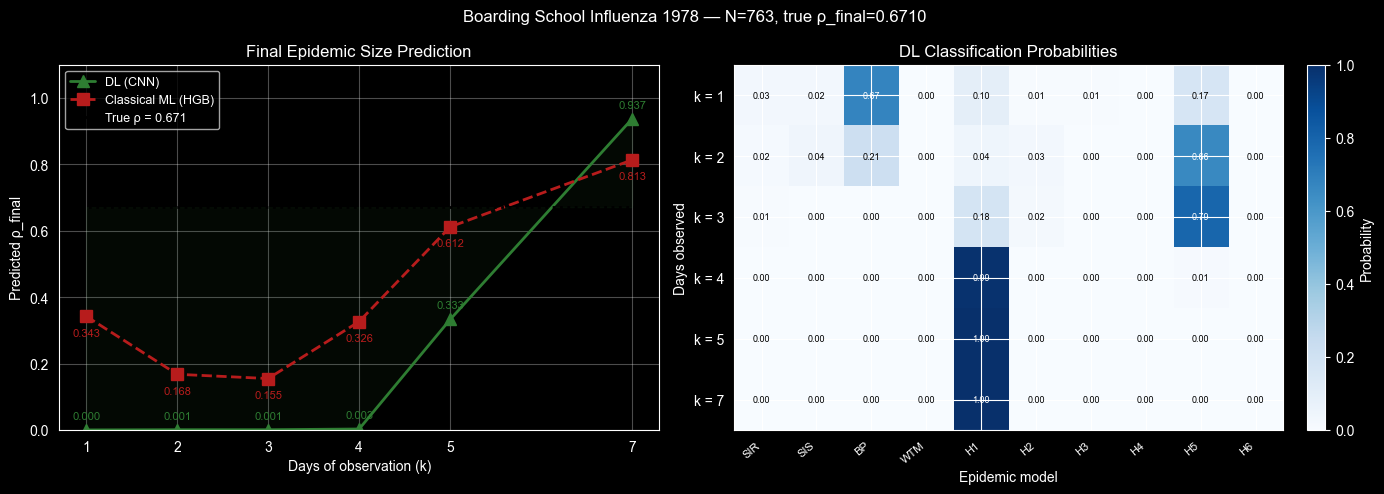

In [8]:
ks   = results_df["days_observed"].values
dl_r = results_df["DL_rho"].values
ml_r = results_df["ML_rho"].values

fig, (ax_rho, ax_prob) = plt.subplots(1, 2, figsize=(14, 5))

# --- rho predictions vs truth ---
ax_rho.plot(ks, dl_r, "^-", color="#2E7D32", lw=2, ms=8, label="DL (CNN)")
ax_rho.plot(ks, ml_r, "s--", color="#B71C1C", lw=2, ms=8, label="Classical ML (HGB)")
ax_rho.axhline(RHO_FINAL_TRUE, color="black", linestyle=":", lw=2,
               label=f"True ρ = {RHO_FINAL_TRUE:.3f}")
ax_rho.fill_between(ks, dl_r, RHO_FINAL_TRUE, alpha=0.07, color="#2E7D32")

for k, rd, rm in zip(ks, dl_r, ml_r):
    ax_rho.annotate(f"{rd:.3f}", (k, rd), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=8, color="#2E7D32")
    ax_rho.annotate(f"{rm:.3f}", (k, rm), xytext=(0, -14),
                    textcoords="offset points", ha="center", fontsize=8, color="#B71C1C")

ax_rho.set_xlabel("Days of observation (k)")
ax_rho.set_ylabel("Predicted ρ_final")
ax_rho.set_title("Final Epidemic Size Prediction")
ax_rho.set_ylim(0, 1.1)
ax_rho.set_xticks(ks)
ax_rho.legend(fontsize=9)
ax_rho.grid(alpha=0.3)

# --- DL class probability heatmap ---
prob_mat = np.array([dl_probas[k] for k in OBS_WINDOWS])
im = ax_prob.imshow(prob_mat, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax_prob.set_xticks(range(10))
ax_prob.set_xticklabels(MODEL_NAMES, fontsize=8, rotation=40, ha="right")
ax_prob.set_yticks(range(len(OBS_WINDOWS)))
ax_prob.set_yticklabels([f"k = {k}" for k in OBS_WINDOWS])
ax_prob.set_title("DL Classification Probabilities")
ax_prob.set_xlabel("Epidemic model")
ax_prob.set_ylabel("Days observed")
for i in range(len(OBS_WINDOWS)):
    for j in range(10):
        v = prob_mat[i, j]
        ax_prob.text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=6.5, color="white" if v > 0.55 else "black")
plt.colorbar(im, ax=ax_prob, fraction=0.046, pad=0.04, label="Probability")

fig.suptitle(
    f"Boarding School Influenza 1978 — N={N_POPULATION}, true ρ_final={RHO_FINAL_TRUE:.4f}",
    fontsize=12,
)
plt.tight_layout()

plot_path = RESULTS_DIR / "boarding_school_predictions.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved → {plot_path}")
plt.show()

## 8. Summary

In [9]:
best_dl = results_df.loc[results_df["DL_err"].idxmin()]
best_ml = results_df.loc[results_df["ML_err"].idxmin()]

print(f"True ρ_final = {RHO_FINAL_TRUE:.4f}  ({TOTAL_INFECTED}/{N_POPULATION} boys infected)")
print()
print(f"Best DL prediction: k={int(best_dl['days_observed'])} days → "
      f"rho={best_dl['DL_rho']:.4f}, class={best_dl['DL_class']}, |err|={best_dl['DL_err']:.4f}")
print(f"Best ML prediction: k={int(best_ml['days_observed'])} days → "
      f"rho={best_ml['ML_rho']:.4f}, class={best_ml['ML_class']}, |err|={best_ml['ML_err']:.4f}")

# Save text report
lines = [
    "Boarding School Influenza 1978 — Prediction Summary",
    "=" * 60,
    f"Population N={N_POPULATION}, total infected={TOTAL_INFECTED}",
    f"True rho_final = {RHO_FINAL_TRUE:.4f}",
    f"Observed series: {T} days, peak on day {peak_day}",
    "",
    results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"),
    "",
    f"Best DL | k={int(best_dl['days_observed'])} days  rho={best_dl['DL_rho']:.4f}  "
    f"class={best_dl['DL_class']}  |err|={best_dl['DL_err']:.4f}",
    f"Best ML | k={int(best_ml['days_observed'])} days  rho={best_ml['ML_rho']:.4f}  "
    f"class={best_ml['ML_class']}  |err|={best_ml['ML_err']:.4f}",
]
summary_path = RESULTS_DIR / "boarding_school_summary.txt"
summary_path.write_text("\n".join(lines) + "\n")
print(f"\nReport saved → {summary_path}")

True ρ_final = 0.6710  (512/763 boys infected)

Best DL prediction: k=7 days → rho=0.9371, class=H1, |err|=0.2661
Best ML prediction: k=5 days → rho=0.6115, class=H2, |err|=0.0595

Report saved → /Users/alvarom/Documents/Erasmus/TFG/Bootstrap/src/results/boarding_school/boarding_school_summary.txt
